In [1]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()
model = ChatOpenAI(model="gpt-4o-mini")

In [2]:
from langgraph.graph import MessagesState

class State(MessagesState):
    summary: str

In [3]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Define the logic to call the model
def call_model(state: State):
    # Get summary if it exists
    summary = state.get("summary", "")
    
    # If there is summary, then we add it
    if summary:
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"
        
        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}

In [4]:
def summarize_conversation(state: State):
    # First, we get any existing summary
    summary = state.get("summary", "")
    
    # Create our summarization prompt
    if summary:
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"
    
    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

In [5]:
from langgraph.graph import END

# Determine whether to end or summarize the conversation
def should_continue(state: State):
    """Return the next node to execute."""
    messages = state['messages']
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) >= 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return "end"

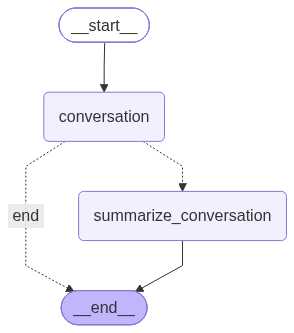

In [9]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

# Define a new graph
workflow = StateGraph(State)

# Add nodes
workflow.add_node("conversation", call_model)
workflow.add_node("summarize_conversation", summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")

# Add conditional edge from conversation node
workflow.add_conditional_edges("conversation", should_continue, {
    "summarize_conversation": "summarize_conversation",
    "end": END
})

# After summarization, end the graph
workflow.add_edge("summarize_conversation", END)

# Compile with checkpointer for memory
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Create a thread (conversation session)
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Siva")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="i Love python !")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()


================================== Ai Message ==================================

Hi Siva! How can I assist you today?
================================== Ai Message ==================================

Your name is Siva. How can I help you today, Siva?
================================== Ai Message ==================================

That's great! Python is a versatile and powerful programming language. What do you love most about it? Are you working on any specific projects or learning anything new?


{'messages': [HumanMessage(content='i Love python !', additional_kwargs={}, response_metadata={}, id='9876c717-143a-48df-a459-157c14309357'),
  AIMessage(content="That's great! Python is a versatile and powerful programming language. What do you love most about it? Are you working on any specific projects or learning anything new?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 64, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f51aa69871', 'id': 'chatcmpl-EU4zuhWoFyCPaAJYEhNvISdl4oWU6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id=

In [11]:
graph.get_state(config).values.get("summary", "")

'In the conversation, Siva introduced themselves and expressed a love for Python. I acknowledged their name and enthusiasm for the programming language, inquired about what they enjoy most about Python, and asked if they were working on any specific projects or learning anything new.'

In [12]:
input_message = HumanMessage(content="tell me about elon musk")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Elon Musk is a prominent entrepreneur and business magnate known for his role in several high-profile technology companies. Here are some key points about him:

1. **Early Life**: Elon Musk was born on June 28, 1971, in Pretoria, South Africa. He showed an early interest in computers and programming, teaching himself to code at a young age.

2. **Zip2 Corporation**: In 1996, Musk co-founded Zip2, a software company that provided business directories and maps for newspapers. It was sold to Compaq in 1999 for approximately $307 million.

3. **X.com and PayPal**: Musk went on to create X.com, an online payment company, which later became PayPal after a merger. PayPal was sold to eBay in 2002 for $1.5 billion in stock.

4. **SpaceX**: In 2002, Musk founded Space Exploration Technologies Corp., or SpaceX, with the goal of reducing space transportation costs and enabling the colonization of Mars. SpaceX has ach

In [13]:
graph.get_state(config).values.get("summary", "")

'In the conversation, Siva introduced themselves and expressed a love for Python. I acknowledged their name and enthusiasm for the programming language, inquired about what they enjoy most about Python, and asked if they were working on any specific projects or learning anything new.'

In [14]:
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage

tools = [TavilySearch(max_results=3)]

# Tool-bound model for the conversation step only.
# summarize_conversation keeps using the plain `model` from section 1.
model_with_tools = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(tools)

def call_model_with_tools(state: State):
    summary = state.get("summary", "")

    if summary:
        system_message = f"Summary of conversation earlier: {summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]

    response = model_with_tools.invoke(messages)
    return {"messages": response}

In [15]:
from langgraph.graph import StateGraph, START, END

summarization_builder = StateGraph(State)
summarization_builder.add_node("conversation", call_model_with_tools)
summarization_builder.add_node("summarize_conversation", summarize_conversation)

summarization_builder.add_edge(START, "conversation")
summarization_builder.add_conditional_edges("conversation", should_continue, {
    "summarize_conversation": "summarize_conversation",
    "end": END
})
summarization_builder.add_edge("summarize_conversation", END)

# No checkpointer: this compiled graph is a node inside the parent.
summarization_subgraph = summarization_builder.compile()

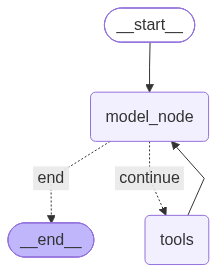

In [16]:
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

def where_to_go(state: State):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "continue"
    else:
        return "end"

parent_builder = StateGraph(State)

# Basics guide: workflow.add_node("agent", function_1)
# function_1 was the model call. Here that node is named model_node.
parent_builder.add_node("model_node", summarization_subgraph)
parent_builder.add_node("tools", ToolNode(tools=tools))

parent_builder.add_conditional_edges("model_node", where_to_go, {
    "continue": "tools",
    "end": END
})
parent_builder.add_edge("tools", "model_node")
parent_builder.set_entry_point("model_node")

parent_memory = MemorySaver()
parent_app = parent_builder.compile(checkpointer=parent_memory)
parent_app

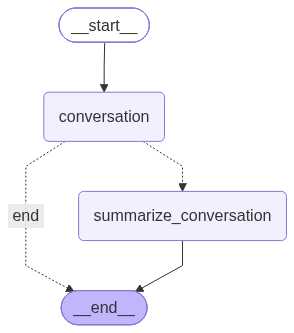

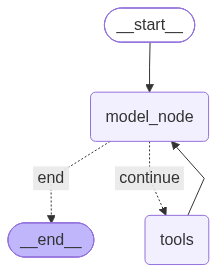

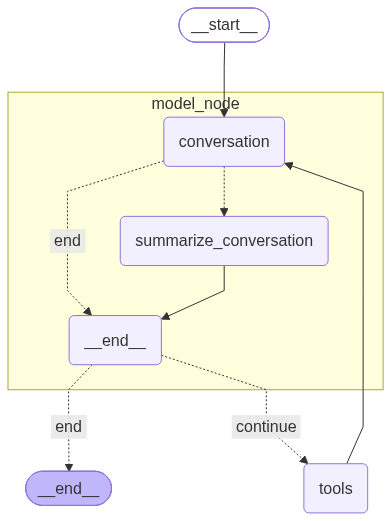

In [17]:
from IPython.display import Image, display

# Summarization subgraph by itself
display(Image(summarization_subgraph.get_graph().draw_mermaid_png()))

# Parent graph: model_node is a single node
display(Image(parent_app.get_graph().draw_mermaid_png()))

# Parent graph with the subgraph expanded
display(Image(parent_app.get_graph(xray=1).draw_mermaid_png()))

# If PNG rendering fails, print Mermaid text and paste it into https://mermaid.live
# print(parent_app.get_graph(xray=1).draw_mermaid())

In [18]:
config = {"configurable": {"thread_id": "subgraph-1"}}

input_message = HumanMessage(content="What are the latest developments in LangGraph?")
output = parent_app.invoke({"messages": [input_message]}, config)
for m in output["messages"][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="hi! I'm Siva")
output = parent_app.invoke({"messages": [input_message]}, config)
for m in output["messages"][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = parent_app.invoke({"messages": [input_message]}, config)
for m in output["messages"][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="I love Python!")
output = parent_app.invoke({"messages": [input_message]}, config)
for m in output["messages"][-1:]:
    m.pretty_print()

parent_app.get_state(config).values.get("summary", "")

================================== Ai Message ==================================

Here are some of the latest developments in LangGraph:

1. **Overview of LangGraph**: LangGraph is an open-source library within the LangChain ecosystem designed for building multi-agent applications using large language models (LLMs). It utilizes graph-based architectures to manage complex relationships between components, allowing for flexible coordination and execution of multiple LLM agents in complex workflows. Key features include robust state management and conditional logic, which enhance the capabilities of AI agents in handling large-scale tasks. [Read more here](https://www.coursera.org/articles/langgraph).

2. **LangGraph vs. LangChain**: A recent discussion highlighted the differences between LangGraph and LangChain, focusing on their respective frameworks for AI agent development. LangGraph is noted for its explicit control over agent state as a graph of nodes and edges, while LangChain offe

"Here's the extended summary of our conversation to date:\n\n1. **Latest Developments in LangGraph**: You asked about the latest developments in LangGraph, and I provided several key points:\n   - **Overview of LangGraph**: It's an open-source library within the LangChain ecosystem designed for building multi-agent applications using large language models. It employs graph-based architectures to manage complex workflows with capabilities in state management and conditional logic.\n   - **Comparison with LangChain**: There was a discussion about the differences between LangGraph and LangChain, highlighting LangGraph's focus on explicit control of agent states compared to the higher-level abstraction offered by LangChain.\n   - **Crash Recovery Features**: Recent updates indicate advancements in crash recovery for LangGraph agents, including features like checkpointers. However, it was noted that additional mechanisms are needed to effectively detect crashes and resume processes.\n\n2. *